/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(



📊 Original quote data: 34,014 quotes from 23,888 customers

🌍 USING ALL REGIONS (no filter)
   Quotes: 34,014 (100.0% of total)
   Customers: 23,888

🏗️  BUILDING FEATURES FOR ALL REGION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 23,888, Quotes: 33,247
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 23,888 customers | 39.6% converters
⏱️  Execution time: 10.3 seconds
⚠️  10.3s (target was 3s)
CREATING FIRST CONVERSION PREDICTION FEATURES (LEAKAGE-FREE)
  Total customers: 23,888
⚡ Processing customers with corrected first-conversion logic...
  Processed 0/23,888 customers
  Processed 5,000/23,888 customers
  Processed 10,000/23,888 customers
  Processed 15,000/23,888 customers
  Processed 20,000/23,888 customers
✅ First-conversion features calculation complete

🔍 VALIDATION REPORT:
   Total customers: 23,888
   First converters: 9,458 (39.6%)

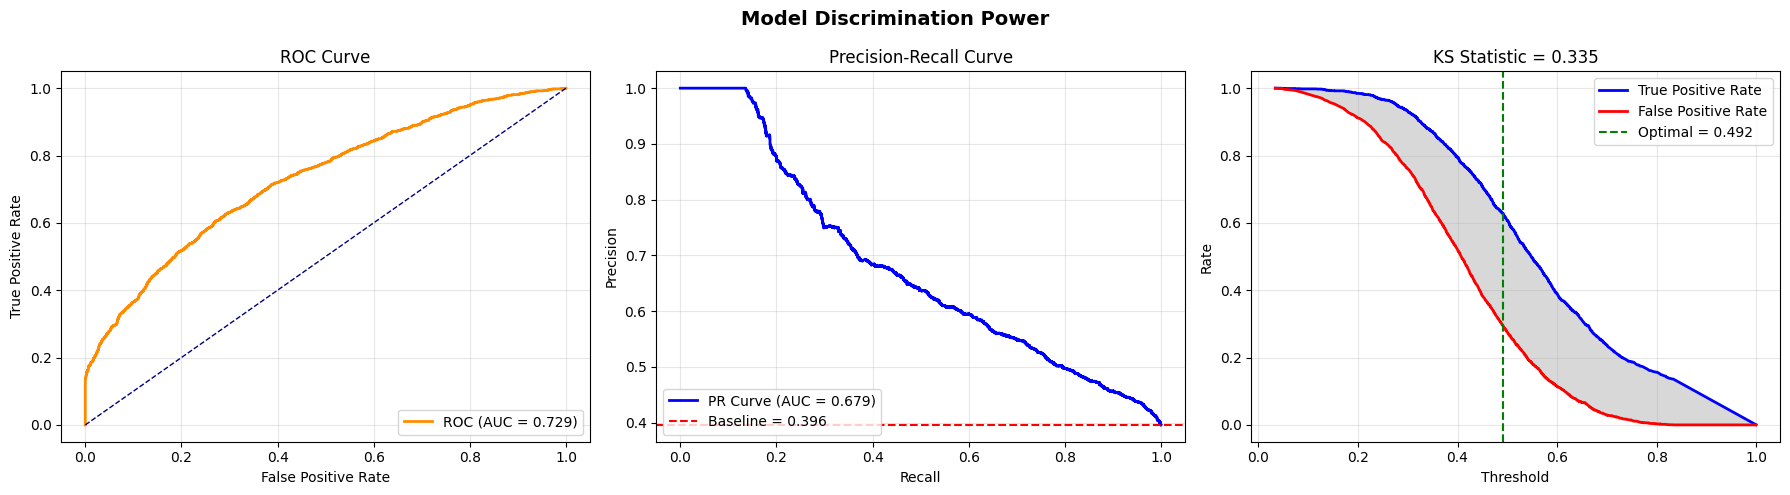

• ROC-AUC: 0.7290
• PR-AUC: 0.6785
• KS Statistic: 0.335 (MODERATE discrimination)
• Optimal Threshold: 0.492

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.885
Decile 10 mean prob: 0.176


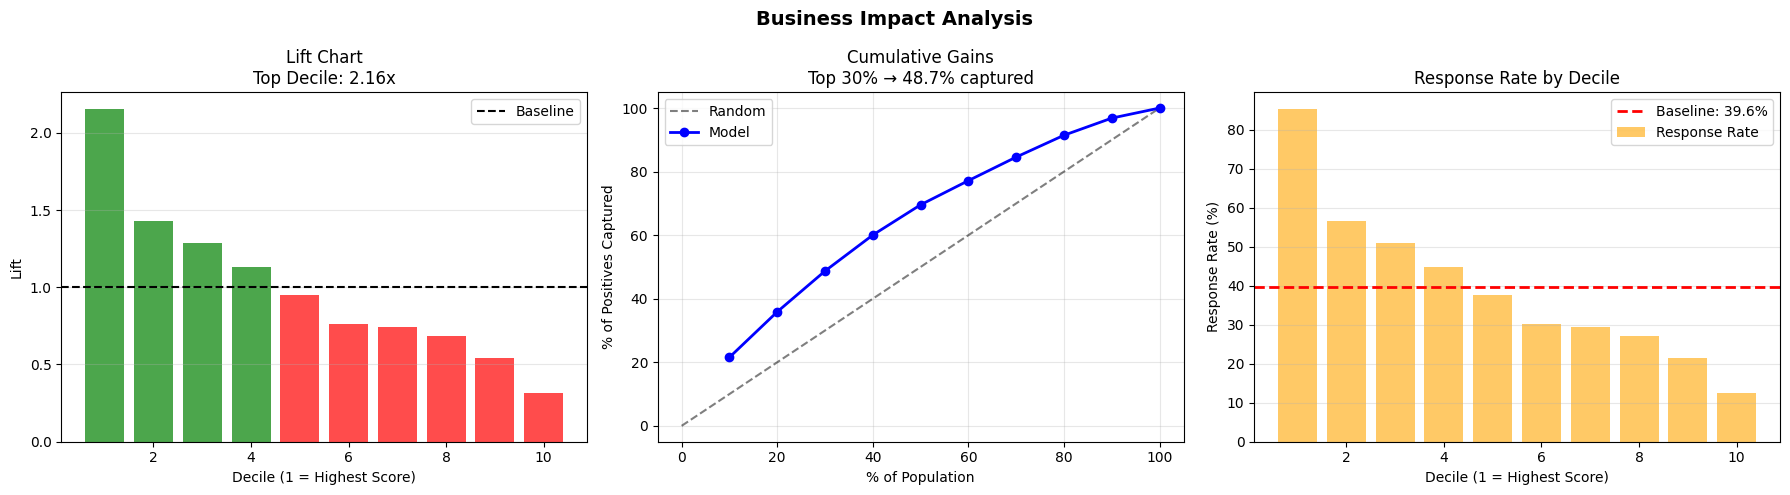

• Top Decile Lift: 0.32x
• Top 30% captures: 48.7% of positives
• Baseline response rate: 39.6%
• Top decile response: 85.4%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


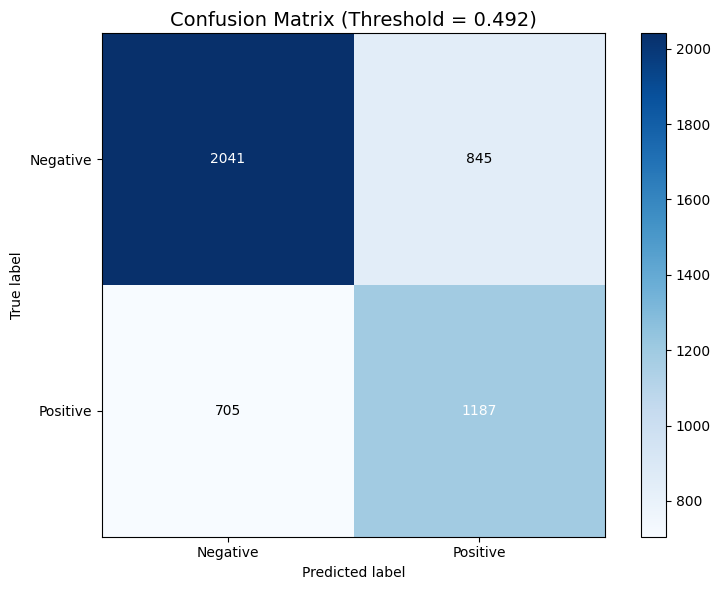

At threshold 0.492:
• Accuracy: 0.676
• Precision: 0.584
• Recall: 0.627
• F1-Score: 0.605
• True Positives: 1187
• False Positives: 845
• True Negatives: 2041
• False Negatives: 705

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.335 (MODERATE discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.32x better than random
   Coverage: Top 30% → 48.7% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.7290 (Excellent if >0.8)
   PR-AUC: 0.6785 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.492
   Precision at threshold: 0.584
   Recall at threshold: 0.627

🔍 FEATURE IMPORTANCE - ALL REGION MODEL

Top 20 Features:
                        feature  importance
171     quote_consistency_score    0.106915
243                 value_score    0.037535
92          primary_system_type    0.021701
47            brand_consistency    0.017654
196  discount_relative_to_price    0.016544
99      max_days_between_quotes    0.014814
63                season_winter    0.014751

KeyError: 'roc_auc'

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

from etl.util import prepare_dataset_without_leakage
from ml_features.features import prepare_features
from ml_features.customer_features import create_customer_features
from ml_features.sequence_features  import create_sequence_features
from ml_features.brand_features import create_brand_features
from ml_features.model_features import create_model_features
from ml_features.market_features import create_market_features
from ml_features.equipment_features import create_equipment_features
from ml_features.solution_complexity_features import create_solution_complexity_features
from ml_features.timeline_features import create_timeline_features, create_advanced_timeline_features, create_timeline_interaction_features
from ml_features.role_features import create_commercial_role_features
from ml_features.process_features import create_process_features
from ml_features.correction_features import create_correction_features
from ml_features.catboost_interaction_features import create_catboost_interaction_features
from ml_features.efficiency_interation_features import create_efficiency_interaction_features
from ml_features.engagement_interation_features import create_engagement_interaction_features
from ml_features.advanced_features import create_advanced_interaction_features, create_conversion_pattern_features, create_precision_optimization_features, create_price_dominant_features
from ml_features.price_binning_features import create_price_binning_features
from ml_features.simulation_discovery import create_simulation_discovery_features
from ml_training.train_xgb import train_xgb
from ml_evaluation.dashboard import model_evaluation_report
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')


# ============================================
# CONFIGURATION - ADJUST THESE PARAMETERS
# ============================================

# Define region groups based on climate
COLD_REGIONS = [
    'Normandie', 'Hauts-de-France', 'Grand Est', 
    'Bourgogne-Franche-Comté', 'Bretagne', 'Centre-Val de Loire'
]

WARM_REGIONS = [
    'Provence-Alpes-Côte d\'Azur', 'PACA', 'Occitanie', 
    'Corse', 'Nouvelle-Aquitaine'
]

TEMPERATE_REGIONS = [
    'Auvergne-Rhône-Alpes', 'Île-de-France', 'Pays de la Loire'
]

# Select which region to analyze
# Options: 'all', 'cold', 'warm', 'temperate'
REGION_FILTER = 'all'  # Change this to 'cold' or 'warm' to filter

# Model training parameters
MODEL_NAME = f"conversion_model_{REGION_FILTER}"
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Feature list (from your pipeline)
FEATURE_FUNCS = [
    create_customer_features, 
    create_sequence_features, 
    create_brand_features, 
    create_model_features, 
    create_market_features,
    create_equipment_features, 
    create_solution_complexity_features,
    create_timeline_features, 
    create_advanced_timeline_features,
    create_commercial_role_features, 
    create_process_features,
    create_correction_features
]

# Helper function to ensure consistent column types
def ensure_string_id(df):
    """Ensure 'numero_compte' column is string type"""
    if 'numero_compte' in df.columns:
        df['numero_compte'] = df['numero_compte'].astype(str)
    return df

# ============================================
# DATA LOADING
# ============================================

df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])
df_quotes_original = df_quotes.copy()
print(f"\n📊 Original quote data: {len(df_quotes):,} quotes from {df_quotes['numero_compte'].nunique():,} customers")

# ============================================
# APPLY REGION FILTER
# ============================================

if REGION_FILTER == 'cold':
    df_quotes = df_quotes[df_quotes['nom_region'].isin(COLD_REGIONS)].copy()
    print(f"\n❄️ FILTERED TO COLD REGIONS ONLY:")
elif REGION_FILTER == 'warm':
    df_quotes = df_quotes[df_quotes['nom_region'].isin(WARM_REGIONS)].copy()
    print(f"\n☀️ FILTERED TO WARM REGIONS ONLY:")
elif REGION_FILTER == 'temperate':
    df_quotes = df_quotes[df_quotes['nom_region'].isin(TEMPERATE_REGIONS)].copy()
    print(f"\n🌤️ FILTERED TO TEMPERATE REGIONS ONLY:")
else:
    print(f"\n🌍 USING ALL REGIONS (no filter)")

# Ensure ID is string after filtering
df_quotes = ensure_string_id(df_quotes)

print(f"   Quotes: {len(df_quotes):,} ({len(df_quotes)/len(df_quotes_original)*100:.1f}% of total)")
print(f"   Customers: {df_quotes['numero_compte'].nunique():,}")

# ============================================
# RUN FEATURE PIPELINE
# ============================================

print("\n" + "="*80)
print(f"🏗️  BUILDING FEATURES FOR {REGION_FILTER.upper()} REGION CUSTOMERS")
print("="*80)

# First feature function
new_df = FEATURE_FUNCS[0](df_quotes)
new_df = ensure_string_id(new_df)
customer_df = new_df.copy()

# Remaining feature functions
for func in FEATURE_FUNCS[1:]:
    new_df_ = func(df_quotes)
    new_df_ = ensure_string_id(new_df_)
    
    new_df = pd.merge(new_df, new_df_, on='numero_compte', how='left', suffixes=('_dup', ''))
    new_df = new_df.drop(columns=[x for x in new_df.columns if '_dup' in x], errors='ignore')
    
    if func == create_sequence_features:
        sequence_df = new_df.copy()

print(f"\n✅ Customer-level features created: {len(new_df):,} customers")

# ============================================
# ADD INTERACTION FEATURES
# ============================================

print("\n" + "="*80)
print("🔧 ADDING INTERACTION FEATURES")
print("="*80)

new_df = create_timeline_interaction_features(new_df)
new_df, _ = create_catboost_interaction_features(new_df)
new_df, _ = create_efficiency_interaction_features(new_df)
new_df, _ = create_engagement_interaction_features(new_df)
new_df = create_advanced_interaction_features(new_df)
new_df = create_conversion_pattern_features(new_df)
new_df = create_precision_optimization_features(new_df)
new_df = create_price_dominant_features(new_df) 
new_df = create_price_binning_features(new_df)
new_df = create_simulation_discovery_features(new_df)

# ============================================
# PREPARE FEATURES FOR MODELING
# ============================================

print("\n" + "="*80)
print("🔧 ENCODING & PREPARING FOR MODELING")
print("="*80)

y = new_df['converted']
X = new_df.drop(columns=['numero_compte', 'converted'], errors='ignore')
X_clean, y_clean = prepare_features(X, y, f"{REGION_FILTER.upper()} Region Features")

print(f"   Features: {X_clean.shape[1]}, Samples: {X_clean.shape[0]}")

# ============================================
# TRAIN MODEL
# ============================================

print("\n" + "="*80)
print(f"🚀 TRAINING MODEL ON {REGION_FILTER.upper()} REGION CUSTOMERS")
print("="*80)

result = train_xgb(X_clean, y_clean, MODEL_NAME)

# ============================================
# EVALUATE MODEL
# ============================================

print("\n" + "="*80)
print(f"📊 MODEL EVALUATION - {REGION_FILTER.upper()} REGION")
print("="*80)

df_eval = result['X_test'].copy()
df_eval['converted'] = result['y_test']

model_evaluation_report(df_eval, result['model'], result['features'], 'converted')

# ============================================
# FEATURE IMPORTANCE
# ============================================

print("\n" + "="*80)
print(f"🔍 FEATURE IMPORTANCE - {REGION_FILTER.upper()} REGION MODEL")
print("="*80)

feature_importance = pd.DataFrame({
    'feature': result['features'],
    'importance': result['model'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Features:")
print(feature_importance.head(20))

# ============================================
# SIMULATION-DISCOVERY FEATURES CHECK
# ============================================

print("\n" + "="*80)
print("🧪 SIMULATION-DISCOVERY FEATURES")
print("="*80)

simulation_features = [
    'heat_pump_to_stove_opportunity', 
    'boiler_to_ac_opportunity',
    'cold_region_heat_pump',
    'cold_heat_pump_to_stove',
    'follow_up_opportunity'
]

print("\nFeature Importances for Simulation-Discovery Features:")
for feat in simulation_features:
    if feat in feature_importance['feature'].values:
        imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
        rank = feature_importance[feature_importance['feature'] == feat].index[0] + 1
        print(f"  #{rank}: {feat}: {imp:.4f}")
    else:
        print(f"  ❌ {feat}: NOT FOUND")

# ============================================
# SUMMARY
# ============================================

print("\n" + "="*80)
print(f"✅ MODEL TRAINING COMPLETE - {REGION_FILTER.upper()} REGION")
print("="*80)
print(f"\n📊 Region: {REGION_FILTER.upper()}")
print(f"   Customers: {len(df_quotes['numero_compte'].unique()):,}")
print(f"   Model ROC-AUC: {result['roc_auc']:.4f}")
if 'decile_stats' in result:
    print(f"   Top decile response: {result['decile_stats'].iloc[0]['response_rate']:.1%}")

In [ ]:
X_test = result['X_test'].copy()  # Make a copy to avoid modifying the original
y_test = result['y_test']
model = result['model']

# Ensure X_test doesn't have the target column
if 'converted' in X_test.columns:
    X_test = X_test.drop(columns=['converted'])

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

# Create a dataframe for error analysis that includes the predictions
error_df = X_test.copy()
error_df['converted'] = y_test
error_df['predicted'] = y_pred
if y_pred_proba is not None:
    error_df['prediction_probability'] = y_pred_proba

error_results = comprehensive_error_analysis(
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred,
    y_pred_proba=y_pred_proba,
    original_df=error_df,  # Use the properly prepared dataframe
    customer_id_col='numero_compte'
)

analyze_feature_contribution_to_errors(model, X_test, y_test, y_pred)
create_error_visualization(error_results, y_test, y_pred, y_pred_proba)